### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
import kagglehub
import pandas as pd

In [2]:
import concurrent
import io
import logging
import re
import re2

import cairosvg
import kagglehub
import torch
from lxml import etree
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

svg_constraints = kagglehub.package_import('metric/svg-constraints')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('DEVICE', DEVICE)

class SVGSanitizer:
    def __init__(self, constraints, default_svg):
        self.constraints = constraints
        self.default_svg = default_svg
    
    def enforce_constraints(self, svg_string: str) -> str:
        """Enforces constraints on an SVG string, removing disallowed elements
        and attributes.

        Parameters
        ----------
        svg_string : str
            The SVG string to process.

        Returns
        -------
        str
            The processed SVG string, or the default SVG if constraints
            cannot be satisfied.
        """
        logging.info('Sanitizing SVG...')

        try:
            parser = etree.XMLParser(remove_blank_text=True, remove_comments=True)
            root = etree.fromstring(svg_string, parser=parser)
        except etree.ParseError as e:
            logging.error('SVG Parse Error: %s. Returning default SVG.', e)
            return self.default_svg
    
        elements_to_remove = []
        for element in root.iter():
            try:
                tag_name = etree.QName(element.tag).localname
            except ValueError as e:
                return self.default_svg
    
            # Remove disallowed elements
            if tag_name not in self.constraints.allowed_elements:
                elements_to_remove.append(element)
                continue  # Skip attribute checks for removed elements
    
            # Remove disallowed attributes
            attrs_to_remove = []
            for attr in element.attrib:
                attr_name = etree.QName(attr).localname
                if (
                    attr_name
                    not in self.constraints.allowed_elements[tag_name]
                    and attr_name
                    not in self.constraints.allowed_elements['common']
                ):
                    attrs_to_remove.append(attr)
    
            for attr in attrs_to_remove:
                logging.debug(
                    'Attribute "%s" for element "%s" not allowed. Removing.',
                    attr,
                    tag_name,
                )
                del element.attrib[attr]
    
            # Check and remove invalid href attributes
            for attr, value in element.attrib.items():
                 if etree.QName(attr).localname == 'href' and not value.startswith('#'):
                    logging.debug(
                        'Removing invalid href attribute in element "%s".', tag_name
                    )
                    del element.attrib[attr]

            # Validate path elements to help ensure SVG conversion
            if tag_name == 'path':
                d_attribute = element.get('d')
                if not d_attribute:
                    logging.warning('Path element is missing "d" attribute. Removing path.')
                    elements_to_remove.append(element)
                    continue # Skip further checks for this removed element
                # Use regex to validate 'd' attribute format
                path_regex = re2.compile(
                    r'^'  # Start of string
                    r'(?:'  # Non-capturing group for each command + numbers block
                    r'[MmZzLlHhVvCcSsQqTtAa]'  # Valid SVG path commands (adjusted to exclude extra letters)
                    r'\s*'  # Optional whitespace after command
                    r'(?:'  # Non-capturing group for optional numbers
                    r'-?\d+(?:\.\d+)?(?:[Ee][+-]?\d+)?'  # First number
                    r'(?:[\s,]+-?\d+(?:\.\d+)?(?:[Ee][+-]?\d+)?)*'  # Subsequent numbers with mandatory separator(s)
                    r')?'  # Numbers are optional (e.g. for Z command)
                    r'\s*'  # Optional whitespace after numbers/command block
                    r')+'  # One or more command blocks
                    r'\s*'  # Optional trailing whitespace
                    r'$'  # End of string
                )
                if not path_regex.match(d_attribute):
                    logging.warning(
                        'Path element has malformed "d" attribute format. Removing path.'
                    )
                    elements_to_remove.append(element)
                    continue
                logging.debug('Path element "d" attribute validated (regex check).')
        
        # Remove elements marked for removal
        for element in elements_to_remove:
            if element.getparent() is not None:
                element.getparent().remove(element)
                logging.debug('Removed element: %s', element.tag)

        try:
            cleaned_svg_string = etree.tostring(root, encoding='unicode')
            return cleaned_svg_string
        except ValueError as e:
            logging.error(
                'SVG could not be sanitized to meet constraints: %s', e
            )
            return self.default_svg

class SVGProcessor:
    @staticmethod
    def clean_and_extract_svgs(text, default_svg):
        text = re.sub(r'^.*?(<svg\b)', r'\1', text, flags=re.DOTALL)
        svg_blocks = re.findall(r'<svg\b.*?</svg>', text, re.DOTALL)
    
        if svg_blocks:
            tmp = re.findall(r'<svg\b.*?', svg_blocks[-1], re.DOTALL)
            if len(tmp) > 1:
                tmp2 = svg_blocks[-1].split('<svg')
                return '<svg ' + tmp2[-1]
            else:
                return svg_blocks[-1]
        else:
            if "<svg" in text and "</svg>" not in text:
                text += "</svg>"
                return text
            return default_svg
    
    @staticmethod
    def svg_conversion_check(topic, base_svg_code, default_svg):
        try:
            cairosvg.svg2png(bytestring=base_svg_code.encode('utf-8'), write_to="temp.png")
            return base_svg_code
        except Exception as e:
            print(f"Failed to convert {topic} due to {str(e)}, Returning default SVG.")
            return default_svg


class Model:
    def __init__(self):
        self.model_path = './lora/lora_16bit_merged/' 
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_path)
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_path,
            torch_dtype=torch.float16,
            device_map="auto"
        )
        self.model.eval()
        
        self.default_svg = """<svg width="256" height="256" viewBox="0 0 256 256"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.constraints = svg_constraints.SVGConstraints()
        self.sanitizer = SVGSanitizer(self.constraints, self.default_svg)
    
    def get_response(self, description):
        alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.
    
        ### Instruction:
        Please write an SVG code for the given topic?
    
        ### Input:
        {}
    
        ### Response:
        """
        formatted_input = alpaca_prompt.format(description)
        inputs = self.tokenizer([formatted_input], return_tensors="pt").to(DEVICE)
        outputs = self.model.generate(**inputs, max_new_tokens=1024, use_cache=True)
        return self.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    
    def predict(self, description: str,base_svg_code: str, max_new_tokens=1024) -> str:
        #output_decoded = self.get_response(description)
        #base_svg_code = SVGProcessor.clean_and_extract_svgs(output_decoded, self.default_svg)
        clean_svg_code = self.sanitizer.enforce_constraints(base_svg_code)
        # SVGProcessor.svg_conversion_check(description, clean_svg_code, self.default_svg)
        
        return clean_svg_code



This code could modify your python environment or operating system.

Review this code at https://www.kaggle.com/code/metric/svg-constraints/versions/1
or in your download cache at /home/vino/.cache/kagglehub/notebooks/metric/svg-constraints/output/versions/1

It is strongly recommended that you run this code within a container
such as Docker to provide a secure, isolated execution environment.
See https://www.kaggle.com/docs/packages for more information.

Do you want to proceed? (y)es/[no]:  y


DEVICE cuda


In [3]:
model=Model()

In [4]:
# model.predict('sun rising in the east',\
#               df['Svg'].iloc[2136])

In [5]:
import pandas as pd
df=pd.read_csv('svg_first100k.csv',header=[0])
print(df.shape)
print(df.shape)

(100000, 5)
(100000, 5)


In [6]:
import warnings
import logging
from tqdm import tqdm

# Suppress warnings
warnings.simplefilter("ignore")

# Suppress logging messages
logging.getLogger().setLevel(logging.CRITICAL)
tqdm.pandas()

print(df.shape)
df['clean_svg_code'] = df.progress_apply(lambda x: model.predict(x['caption_blip2'], x['Svg']), axis=1)

(100000, 5)


100%|█████████████████████████████████| 100000/100000 [00:12<00:00, 8270.00it/s]


In [7]:
from transformers import AutoProcessor, AutoModel
model_sl = AutoModel.from_pretrained("google/siglip-so400m-patch14-384").to(DEVICE)
processor_sl = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor_sl(text=texts, images=image, padding="max_length", return_tensors="pt").to(DEVICE)
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model_sl(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [8]:
##### Using apply to process each row in the DataFrame
##### Using apply to process each row in the DataFrame
df['base_score'] = df.progress_apply(lambda row: svgMetric(row['caption_blip2'], row['clean_svg_code']), axis=1)

  0%|▏                                   | 351/100000 [00:22<1:37:31, 17.03it/s]

An error occurred: The SVG size is undefined


  1%|▏                                   | 664/100000 [00:42<1:34:22, 17.54it/s]

An error occurred: The SVG size is undefined


  2%|▌                                  | 1513/100000 [01:39<1:30:18, 18.18it/s]

...

100%|█████████████████████████████████▉| 99793/100000 [1:53:07<00:11, 17.42it/s]

An error occurred: The SVG size is undefined


The channel dimension is ambiguous. Got image shape (1, 205, 3). Assuming channels are the first dimension.
100%|█████████████████████████████████▉| 99957/100000 [1:53:17<00:02, 20.91it/s]

An error occurred: mean must have 1 elements if it is an iterable, got 3
An error occurred: The SVG size is undefined


100%|█████████████████████████████████| 100000/100000 [1:53:20<00:00, 14.70it/s]


In [9]:
df['base_score'].mean()

np.float64(0.08870023543210662)

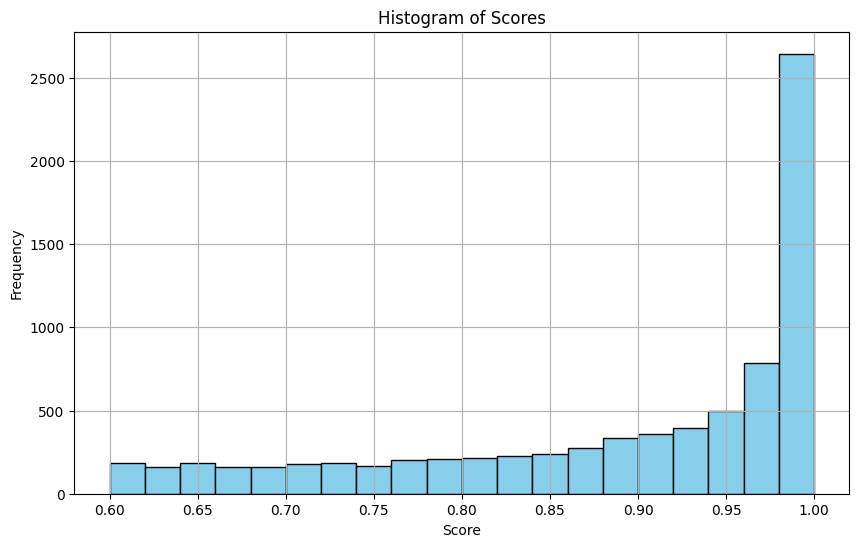

In [10]:
import matplotlib.pyplot as plt
tmp=df[df['base_score']>0.6]
# Plot histogram of the 'score' column
plt.figure(figsize=(10, 6))
plt.hist(tmp['base_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [11]:
df.to_csv('public.csv')